#  Problem Statement
# Client: Calgary Energy Intelligence Solutions (CEIS)
# Task: City of Calgary Electricity Load Prediction using ML

To ensure energy reliability and optimize operations, the City of Calgary is seeking an accurate, data-driven system to predict its hourly electricity demand. The goal is to develop a machine learning model that can forecast electricity load based on historical load and weather data.
This will allow better resource allocation, improved energy efficiency, and smarter grid management, especially under varying weather conditions and peak hours.


# Dataset Overview

The dataset includes hourly electricity load records from 2017 to 2020

Target Variable:
•	load- electricity demand in megawatts (MW)

Feature Variables Include:
* Date-time features (hour, weekday, month, year)
* Weather metrics
 * temperature in Celcius
 * humidity(relaive 2%),
 * wind speed (10km/h)
* Holiday indicators. (0 indicates holiday ond 1 not holiday)

Sourced from:
* AESO (Alberta Electric System Operator): https://www.aeso.ca/market/market-and-system-reporting/data-requests/hourly-load-by-area-and-region
*	Open-Meteo and Environment and Climate Change Canada : https://open-meteo.com/en/docs/historical-weather-api, https://climate.weather.gc.ca/historical_data/search_historic_data_e.html


# Import Dataset

In [8]:
import pandas as pd
from google.colab import files
upload= files.upload()
df = pd.read_csv("DATASET_LOAD_PREDICTION_CALGARY.csv")
print(df.head())

Saving DATASET_LOAD_PREDICTION_CALGARY.csv to DATASET_LOAD_PREDICTION_CALGARY (3).csv
              DATE_MST     Load(MW)  temperature (°C)  wind_speed (km/h)  \
0  2017-01-01 00:00:00  1061.594532              -7.3               13.9   
1  2017-01-01 01:00:00  1017.344971              -8.7               16.5   
2  2017-01-01 02:00:00   983.017740              -9.6               16.0   
3  2017-01-01 03:00:00   960.680297             -10.5               15.3   
4  2017-01-01 04:00:00   951.030604             -11.2               14.3   

   relative_humidity (%)  precipitation (mm)  IS_Holiday  
0                     91                 0.8           0  
1                     91                 0.8           0  
2                     90                 0.6           0  
3                     87                 0.5           0  
4                     86                 0.3           0  


# Dataset Preprocessing and Engineering

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import timedelta
import warnings
warnings.filterwarnings("ignore")

# Load and preprocess data
df = pd.read_csv("DATASET_LOAD_PREDICTION_CALGARY.csv")
df['DATE_MST'] = pd.to_datetime(df['DATE_MST'])
df.sort_values("DATE_MST", inplace=True)
df.reset_index(drop=True, inplace=True)

# Feature Engineering
df['hour'] = df['DATE_MST'].dt.hour
df['dayofweek'] = df['DATE_MST'].dt.dayofweek
df['month'] = df['DATE_MST'].dt.month
df['year'] = df['DATE_MST'].dt.year
df['load_lag1'] = df['Load(MW)'].shift(1)
df['load_lag24'] = df['Load(MW)'].shift(24)
df['load_lag168'] = df['Load(MW)'].shift(168)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# Drop the original datetime column
df.drop(columns=['DATE_MST'], inplace=True)
# Features and target
features = ['temperature (°C)', 'wind_speed (km/h)', 'relative_humidity (%)',
            'precipitation (mm)', 'IS_Holiday', 'hour', 'dayofweek', 'month', 'year',
            'load_lag1', 'load_lag24', 'load_lag168']
X = df[features]
y = df['Load(MW)']
print(df.head())


# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

      Load(MW)  temperature (°C)  wind_speed (km/h)  relative_humidity (%)  \
0  1112.778869             -20.6                7.6                     81   
1  1063.622802             -20.5                6.7                     80   
2  1035.947222             -20.6                6.3                     80   
3  1024.318094             -21.0                6.1                     80   
4  1025.344458             -21.7                5.6                     79   

   precipitation (mm)  IS_Holiday  hour  dayofweek  month  year    load_lag1  \
0                 0.0           1     0          6      1  2017  1178.783171   
1                 0.0           1     1          6      1  2017  1112.778869   
2                 0.0           1     2          6      1  2017  1063.622802   
3                 0.0           1     3          6      1  2017  1035.947222   
4                 0.0           1     4          6      1  2017  1024.318094   

    load_lag24  load_lag168  
0  1110.637201  1061

# Best Model Selection (Linear Regression, Decision Tree and Gradient Boosting)

Running hyperparameter tuning...

Model Comparison Results:
                         MAE       RMSE  R2 Score
Linear Regression  30.944055  40.170574  0.959213
Decision Tree      16.200939  23.351015  0.986218
Gradient Boosting  12.470963  17.134302  0.992579


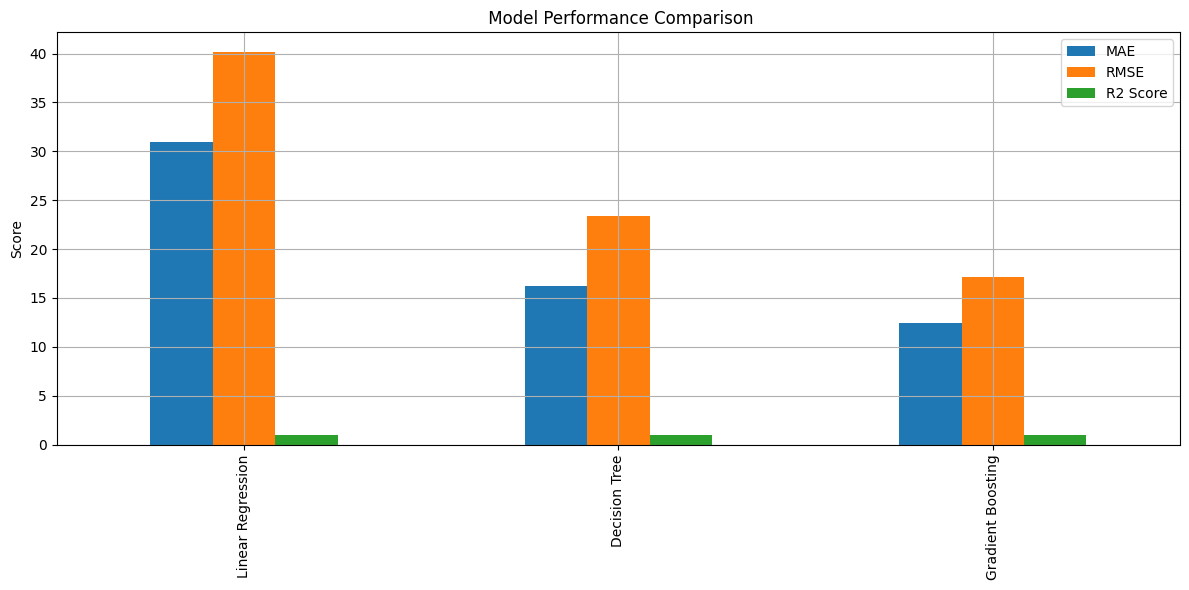


Best Model Selected: Gradient Boosting


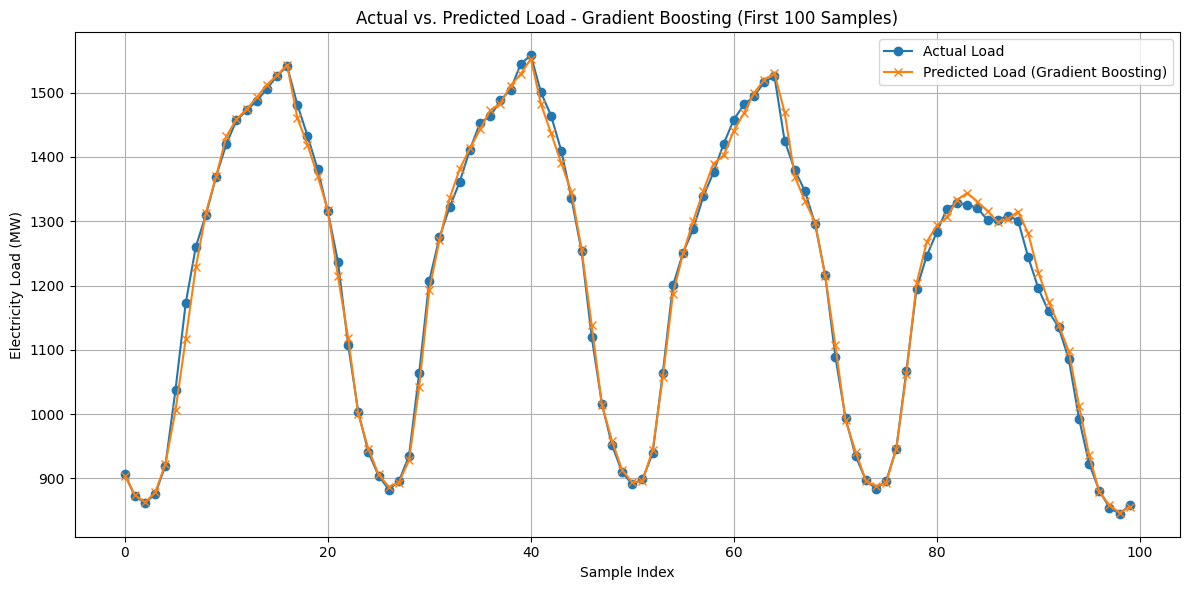

In [14]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter tuning
print("Running hyperparameter tuning...")

# 1. Linear Regression (no tuning needed, included for consistency)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# 2. Decision Tree
dt_param_grid = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}
dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_param_grid, cv=3, scoring='r2', n_jobs=-1)
dt_grid.fit(X_train_scaled, y_train)
dt_model = dt_grid.best_estimator_

# 3. Gradient Boosting
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_param_grid, cv=3, scoring='r2', n_jobs=-1)
gb_grid.fit(X_train_scaled, y_train)
gb_model = gb_grid.best_estimator_

# Collect models
models = {
    "Linear Regression": lr_model,
    "Decision Tree": dt_model,
    "Gradient Boosting": gb_model
}

# Evaluate models
results = {}
predictions_plot = {}

for name, model in models.items():
    preds = model.predict(X_test_scaled)
    predictions_plot[name] = preds
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2 Score": r2_score(y_test, preds)
    }

results_df = pd.DataFrame(results).T
print("\nModel Comparison Results:")
print(results_df)

# Plot model comparison
results_df.plot(kind='bar', figsize=(12, 6))
plt.title(" Model Performance Comparison")
plt.ylabel("Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# Best model
best_model_name = results_df['R2 Score'].idxmax()
best_model = models[best_model_name]
print(f"\nBest Model Selected: {best_model_name}")

gb_preds = models["Gradient Boosting"].predict(X_test_scaled)

plt.figure(figsize=(12, 6))
plt.plot(y_test[:100].values, label="Actual Load", marker='o')
plt.plot(gb_preds[:100], label="Predicted Load (Gradient Boosting)", marker='x')
plt.title("Actual vs. Predicted Load - Gradient Boosting (First 100 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Electricity Load (MW)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Actual_vs_Predicted_GradientBoosting.png")
plt.show()


# Forecasting (next 72 hours, next week, next year and next five year)

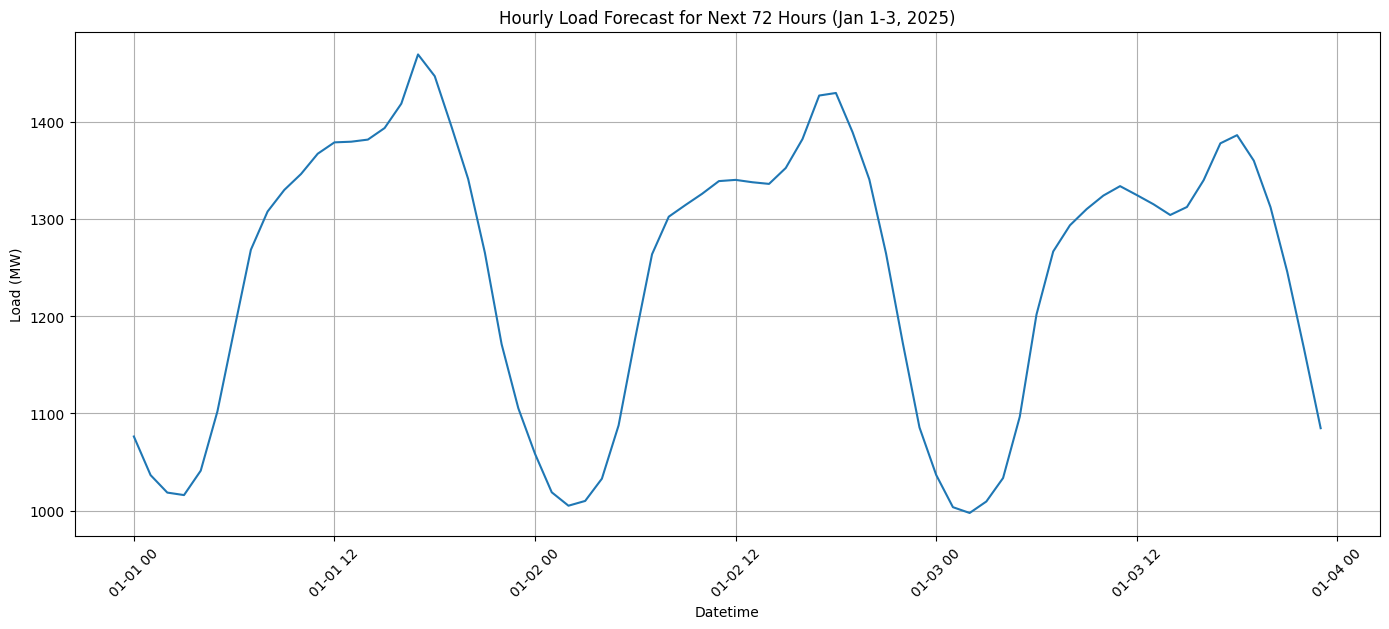

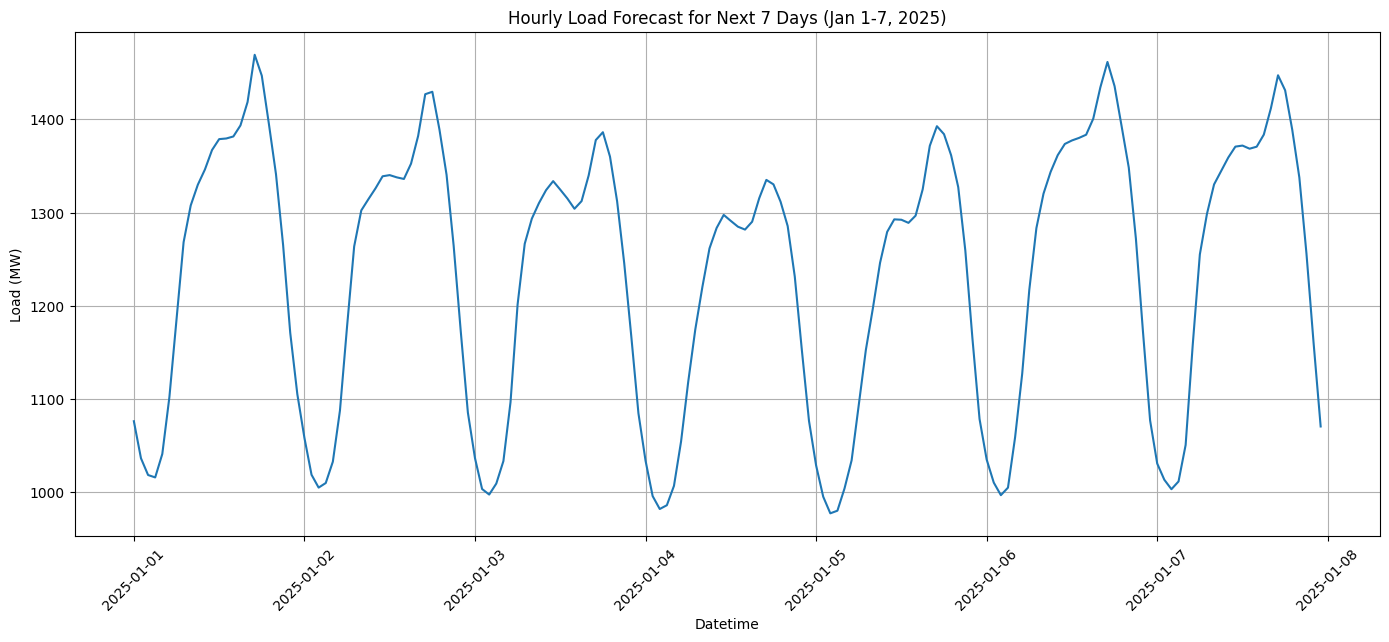

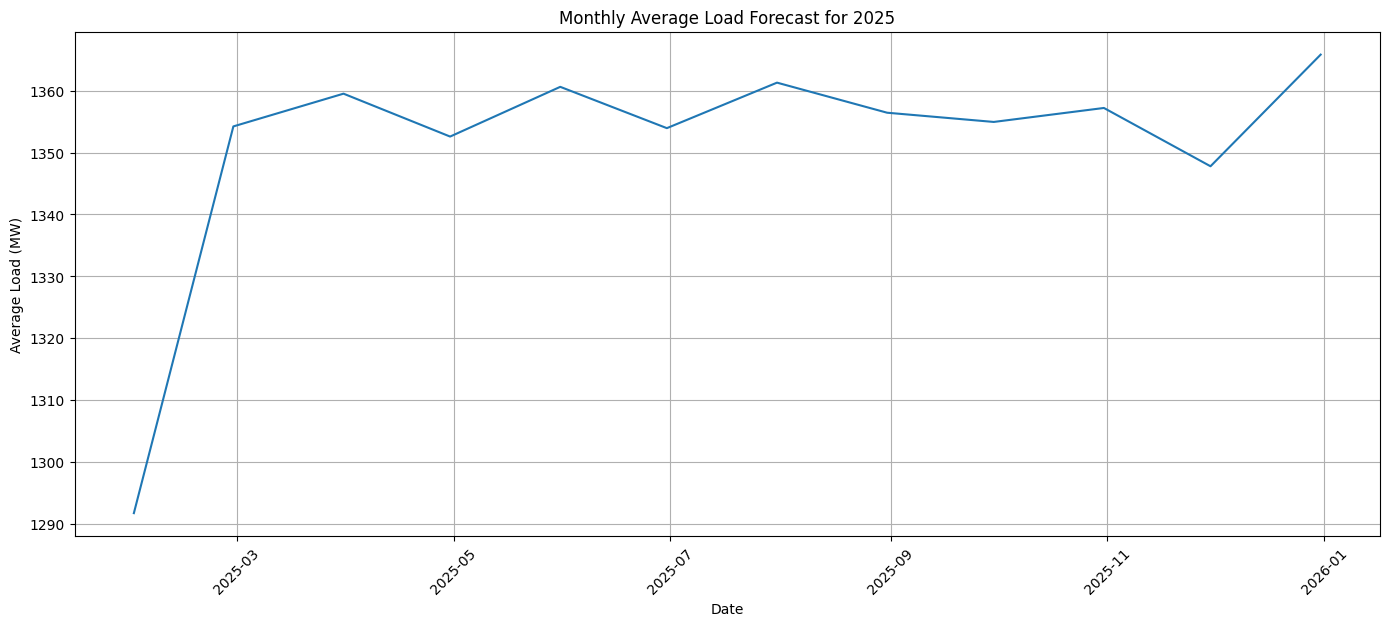

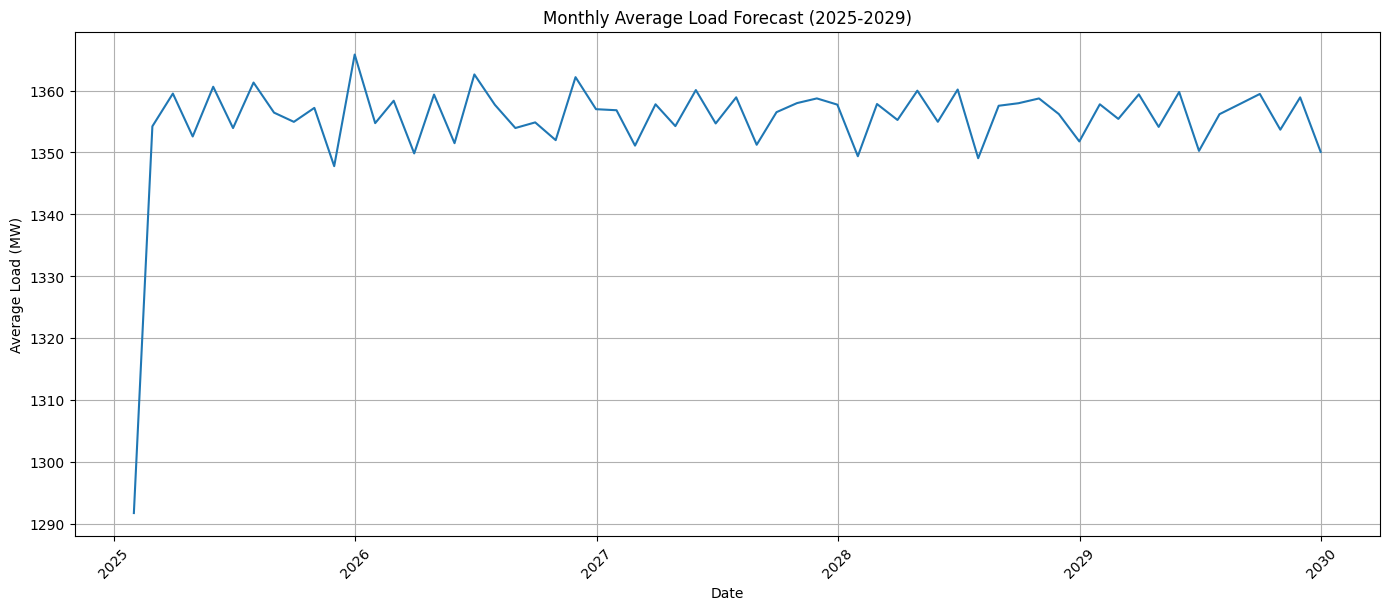

In [15]:
# Fit best model on full data for forecasting
X_scaled = scaler.fit_transform(X)
best_model.fit(X_scaled, y)

# Forecast future load from 2025-01-01
latest_data = df.iloc[-168:].copy()
future_predictions = []
forecast_start_date = pd.Timestamp("2025-01-01 00:00:00")
forecast_horizon = 43800  # 5 years (hours)

for step in range(forecast_horizon):
    last_row = latest_data.iloc[-1].copy()
    new_row = {
        'temperature (°C)': last_row['temperature (°C)'],
        'wind_speed (km/h)': last_row['wind_speed (km/h)'],
        'relative_humidity (%)': last_row['relative_humidity (%)'],
        'precipitation (mm)': last_row['precipitation (mm)'],
        'IS_Holiday': last_row['IS_Holiday'],
        'hour': (last_row['hour'] + 1) % 24,
        'dayofweek': (last_row['dayofweek'] + 1) % 7 if last_row['hour'] == 23 else last_row['dayofweek'],
        'month': last_row['month'] if last_row['hour'] < 23 else ((last_row['month']) % 12) + 1,
        'year': last_row['year'] + 1 if last_row['month'] == 12 and last_row['hour'] == 23 else last_row['year'],
        'load_lag1': last_row['Load(MW)'],
        'load_lag24': latest_data.iloc[-24]['Load(MW)'] if len(latest_data) >= 24 else last_row['Load(MW)'],
        'load_lag168': latest_data.iloc[-168]['Load(MW)'] if len(latest_data) >= 168 else last_row['Load(MW)']
    }
    input_df = pd.DataFrame([new_row])
    input_scaled = scaler.transform(input_df)
    predicted_load = best_model.predict(input_scaled)[0]
    new_row['Load(MW)'] = predicted_load
    latest_data = pd.concat([latest_data, pd.DataFrame([new_row])], ignore_index=True)
    future_predictions.append(predicted_load)

# Create datetime index for forecasts
forecast_index = pd.date_range(start=forecast_start_date, periods=forecast_horizon, freq='H')
future_df = pd.DataFrame({'Datetime': forecast_index, 'Load(MW)': future_predictions})

# Plot next 72 hours forecast
plt.figure(figsize=(14, 6))
plt.plot(future_df['Datetime'][:72], future_df['Load(MW)'][:72])
plt.title("Hourly Load Forecast for Next 72 Hours (Jan 1-3, 2025)")
plt.xlabel("Datetime")
plt.ylabel("Load (MW)")
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

# Plot next 7 days hourly forecast
plt.figure(figsize=(14, 6))
plt.plot(future_df['Datetime'][:168], future_df['Load(MW)'][:168])
plt.title("Hourly Load Forecast for Next 7 Days (Jan 1-7, 2025)")
plt.xlabel("Datetime")
plt.ylabel("Load (MW)")
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


# Plot next 1 year monthly forecast
monthly_1y_avg = future_df.set_index('Datetime')['Load(MW)'].resample('M').mean()[:12]
plt.figure(figsize=(14, 6))
plt.plot(monthly_1y_avg.index, monthly_1y_avg.values)
plt.title("Monthly Average Load Forecast for 2025")
plt.xlabel("Date")
plt.ylabel("Average Load (MW)")
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

# Plot 5-year forecast (monthly average)
monthly_avg = future_df.set_index('Datetime').resample('M').mean()
plt.figure(figsize=(14, 6))
plt.plot(monthly_avg.index, monthly_avg['Load(MW)'])
plt.title("Monthly Average Load Forecast (2025-2029)")
plt.xlabel("Date")
plt.ylabel("Average Load (MW)")
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()
